In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# PACF

#### AR(0)

In [4]:
x0 = np.random.randn(1000)

In [5]:
from statsmodels.tsa.stattools import adfuller

In [6]:
adfuller(x0)

(np.float64(-30.525114764756445),
 0.0,
 0,
 999,
 {'1%': np.float64(-3.4369127451400474),
  '5%': np.float64(-2.864437475834273),
  '10%': np.float64(-2.568312754566378)},
 np.float64(2735.637088111622))

In [7]:
''' data is pretty stationary'''

' data is pretty stationary'

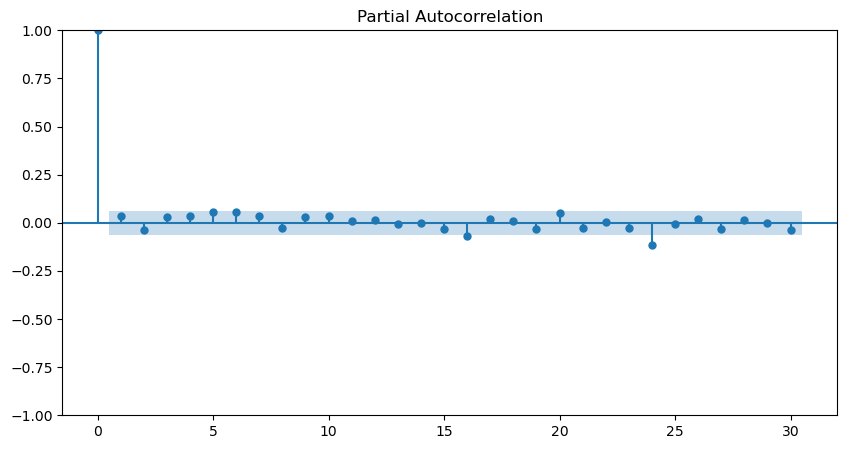

In [8]:
fig,ax = plt.subplots(figsize = (10,5)) # returns an axis object which is used to plot pacf
plot_pacf(x0, ax = ax);

In [9]:
''' the 1st value at lag 0 is 1 since it is just the autocorrelation.
also, pacf whenever it is going outside the confidence interval, is barely crossing the threshold boundary - so ok to ignore them
for some lags, pacf is going outside the confidence interval - this is allowed to happen 5% of the time
since we already know that data we are plotting is just random noise from normal distribution, there is should not be any correlation at lag>0'''

' the 1st value at lag 0 is 1 since it is just the autocorrelation.\nalso, pacf whenever it is going outside the confidence interval, is barely crossing the threshold boundary - so ok to ignore them\nfor some lags, pacf is going outside the confidence interval - this is allowed to happen 5% of the time\nsince we already know that data we are plotting is just random noise from normal distribution, there is should not be any correlation at lag>0'

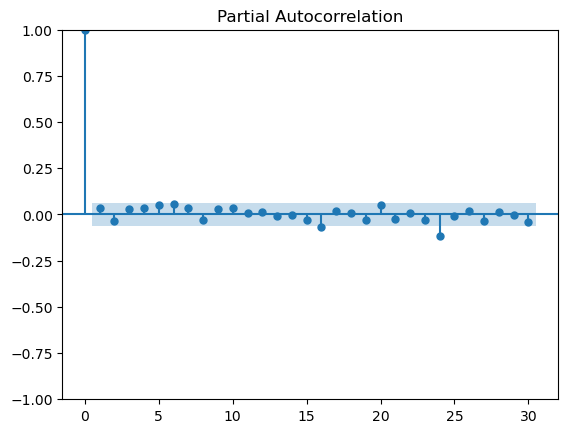

In [10]:
plot_pacf(x0); # just checked if this also works - and yes it does 

#### AR(1)

In [11]:
# creating an artificial AR(1) process - y(t) has relationship with y(t+1)
x1 =[0]
for i in range(1000):
    x  = 0.5 * x1[-1] + 0.1 * np.random.randn()
    x1.append(x)
x1 = np.array(x1)

In [12]:
x1

array([ 0.        ,  0.0937507 ,  0.06207459, ...,  0.0940953 ,
       -0.06734491, -0.11764338])

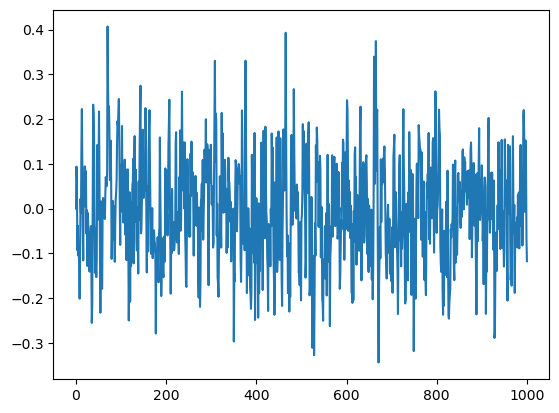

In [13]:
plt.plot(x1)

In [14]:
adfuller(x1)

(np.float64(-17.86790526168868),
 np.float64(3.0355491269565406e-30),
 0,
 1000,
 {'1%': np.float64(-3.4369061654329998),
  '5%': np.float64(-2.86443457404),
  '10%': np.float64(-2.568311209)},
 np.float64(-1716.4248514160372))

In [15]:
'''x1 again pretty stationary'''

'x1 again pretty stationary'

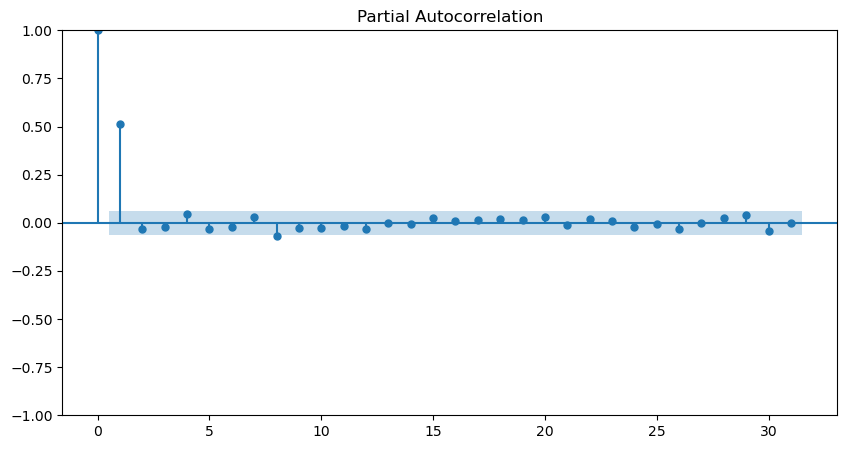

In [16]:
fig, ax = plt.subplots(figsize = (10,5))
plot_pacf(x1, ax=ax);

In [17]:
'''clearly shows that time series is an AR(1) process,
also notice that the pacf at lag 1 is 0.5 which is the orginal relationship which we artificially created where x(t) = 0.5x(t-1)'''

'clearly shows that time series is an AR(1) process,\nalso notice that the pacf at lag 1 is 0.5 which is the orginal relationship which we artificially created where x(t) = 0.5x(t-1)'

In [18]:
x1 = [0]
for i in range(1000):
    x = -0.5*x1[-1] + 0.1*np.random.randn()
    x1.append(x)
x1 = np.array(x1)

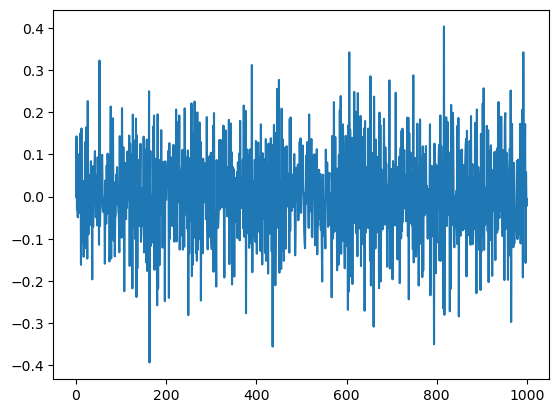

In [19]:
plt.plot(x1)

In [20]:
adfuller(x1)

(np.float64(-54.470882546836016),
 0.0,
 0,
 1000,
 {'1%': np.float64(-3.4369061654329998),
  '5%': np.float64(-2.86443457404),
  '10%': np.float64(-2.568311209)},
 np.float64(-1750.8742097690383))

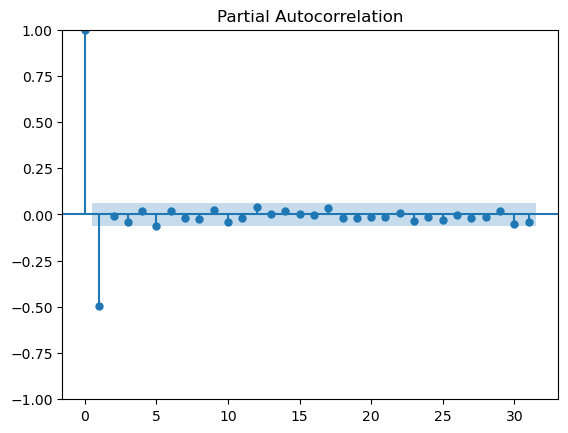

In [21]:
plot_pacf(x1);

#### AR(2)

time series will depend linearly on 2 past values instead of just 1

In [22]:
x2 = [0,0]
for i in range(1000):
    x = 0.5 * x2[-1] - 0.3 * x2[-2] + 0.1 * np.random.randn()
    x2.append(x)
x2 = np.array(x2)

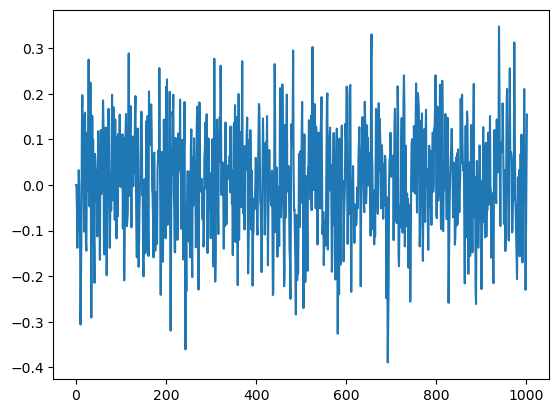

In [23]:
plt.plot(x2)

In [24]:
adfuller(x2)

(np.float64(-9.76820027962084),
 np.float64(7.253852062179239e-17),
 9,
 992,
 {'1%': np.float64(-3.436959175494265),
  '5%': np.float64(-2.8644579524531975),
  '10%': np.float64(-2.568323660940752)},
 np.float64(-1698.7172029233425))

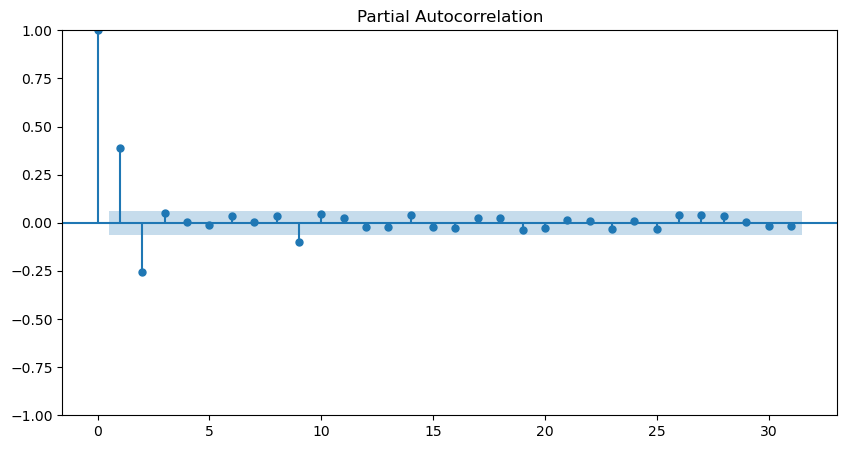

In [25]:
fig, ax = plt.subplots(figsize = (10,5))
plot_pacf(x2,ax=ax);

In [26]:
''' notice that the pacf values are same as the coefficients which were used to generate the array'''

' notice that the pacf values are same as the coefficients which were used to generate the array'

In [27]:
'''we would have choosen p = 2 from the above for AR model'''

'we would have choosen p = 2 from the above for AR model'

#### AR(5) model

In [29]:
x5 = [0,0,0,0,0]
for i in range(1000):
    x = 0.5 * x5[-1] - 0.3 * x5[-2] - 0.6 * x5[-5] + 0.1 * np.random.randn()
    x5.append(x)
x5 = np.array(x5)

''' notice that the next value above doesnt depend upon all the last 5 values, but last value, last to last value and 5 values behind
and doesnt depend on 3 values behind and 4 values behind'''

' notice that the next value above doesnt depend upon all the last 5 values, but last value, last to last value and 5 values behind\nand doesnt depend on 3 values behind and 4 values behind'

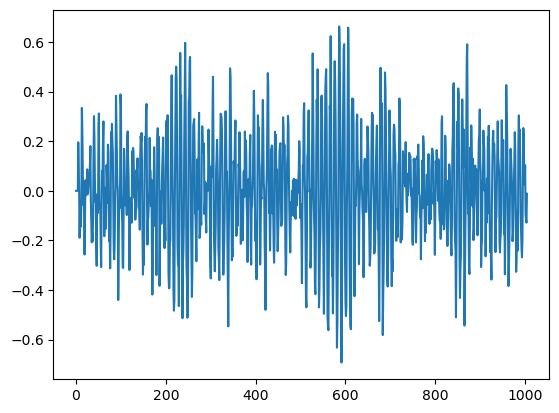

In [31]:
plt.plot(x5)

In [32]:
adfuller(x5)

(np.float64(-41.29344649459404),
 0.0,
 4,
 1000,
 {'1%': np.float64(-3.4369061654329998),
  '5%': np.float64(-2.86443457404),
  '10%': np.float64(-2.568311209)},
 np.float64(-1709.348713785604))

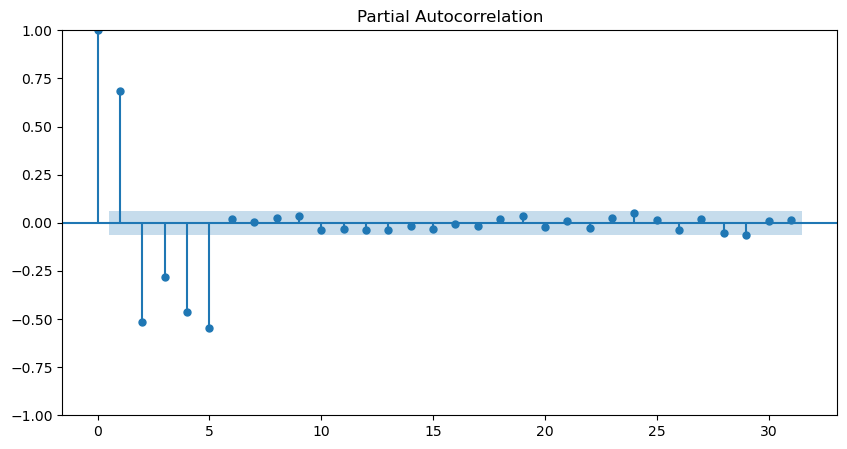

In [33]:
fig, ax = plt.subplots(figsize = (10,5))
plot_pacf(x5,ax=ax);

In [34]:
'''notice that our time series doesnt depend on lag 3 and lag 4 values but depended only on lag 1, lag 2 and lag 5 values, pacf for
lag 3 and lag 4 are still non zero.
notice the pacf values coming at diff lags are now not the same as the coefficients used to generate the noise.
specifically, pacf is coming  higher than confidence interval for 3 values and 4 values behind which has no relationship.
and also pacf for last lag 1 is coming out to be 0.6, but should have been 0.5 etc'''

'notice that our time series doesnt depend on lag 3 and lag 4 values but depended only on lag 1, lag 2 and lag 5 values, pacf for\nlag 3 and lag 4 are still non zero.\nnotice the pacf values coming at diff lags are now not the same as the coefficients used to generate the noise.\nspecifically, pacf is coming  higher than confidence interval for 3 values and 4 values behind which has no relationship.\nand also pacf for last lag 1 is coming out to be 0.6, but should have been 0.5 etc'

# ACF

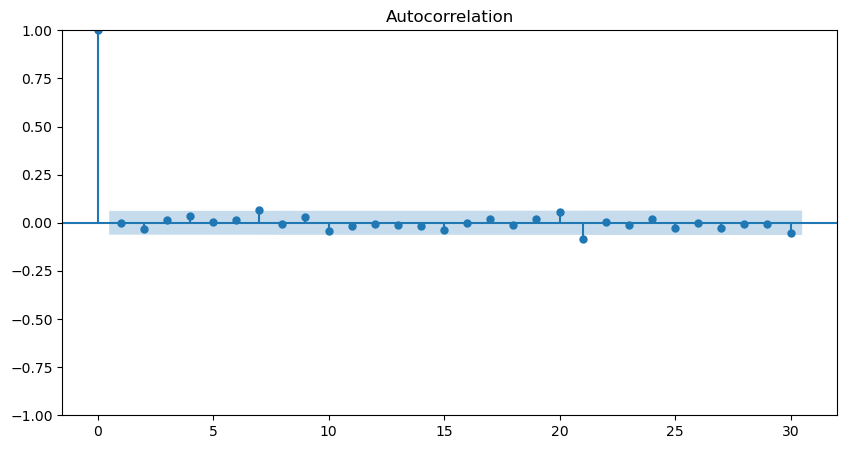

In [36]:
fig, ax = plt.subplots(figsize = (10,5))
plot_acf(np.random.randn(1000),ax=ax);

In [37]:
''' there is no correlation  tou>0'''

' there is no correlation  tou>0'

#### ma(1)

In [39]:
errors = 0.1 * np.random.randn(1000) ## normal distribution with std dev = 0.1
ma1 = []
for i in range(1000):
    if i>=1:
        x = 0.5 * errors[i-1] + errors[i] # ma1 is generted by adding current error times b * previous error
    else:
        x = errors[i]
    ma1.append(x)
    
ma1 = np.array(ma1)

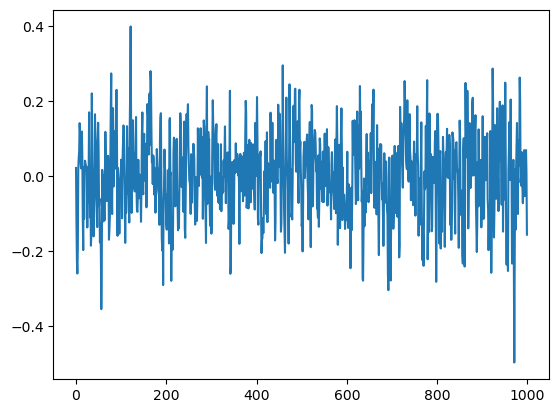

In [43]:
plt.plot(ma1);

In [46]:
adfuller(ma1)

(np.float64(-16.020009523860686),
 np.float64(6.219460894552345e-29),
 2,
 997,
 {'1%': np.float64(-3.4369259442540416),
  '5%': np.float64(-2.8644432969122833),
  '10%': np.float64(-2.5683158550174094)},
 np.float64(-1776.9166849801268))

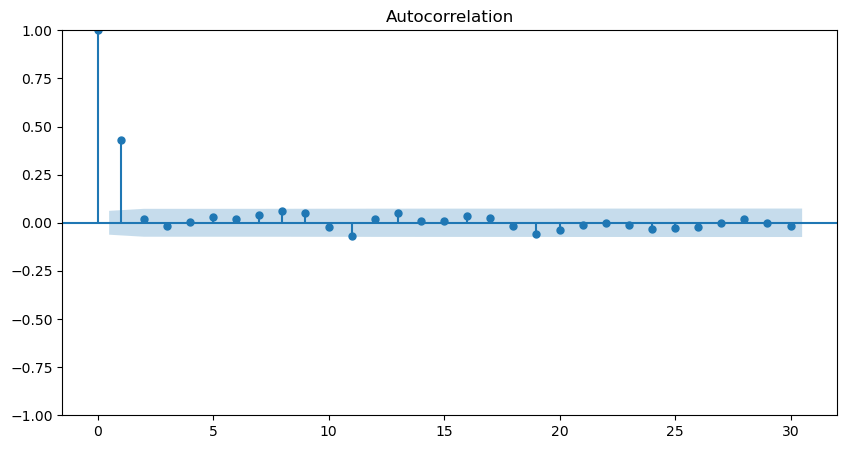

In [47]:
fig, ax = plt.subplots(figsize = (10,5))
plot_acf(ma1, ax=ax);

#### MA(2)

In [50]:
errors = 0.1 * np.random.randn(1000) ## normal distribution with std dev = 0.1
ma2 = []
for i in range(1000):
    # if i>=1:
    x = 0.5 * errors[i-1] - 0.3 * errors[i-2] + errors[i] # ma1 is generted by adding current error times b * previous error
    # else:
        # x = errors[i]
    ma2.append(x)
    
ma2 = np.array(ma2)

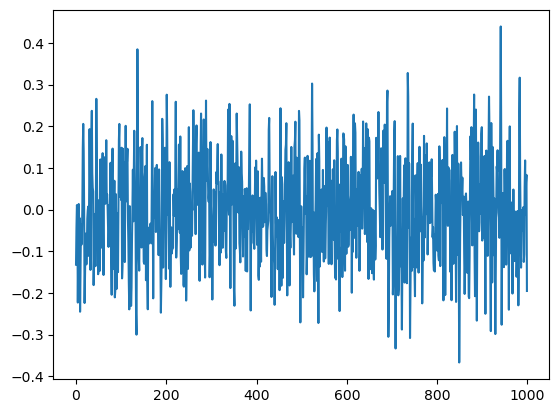

In [54]:
plt.plot(ma2)

In [55]:
adfuller(ma2)

(np.float64(-9.505198926274403),
 np.float64(3.3618475500935693e-16),
 11,
 988,
 {'1%': np.float64(-3.4369860032923145),
  '5%': np.float64(-2.8644697838498376),
  '10%': np.float64(-2.5683299626694422)},
 np.float64(-1657.8915170232685))

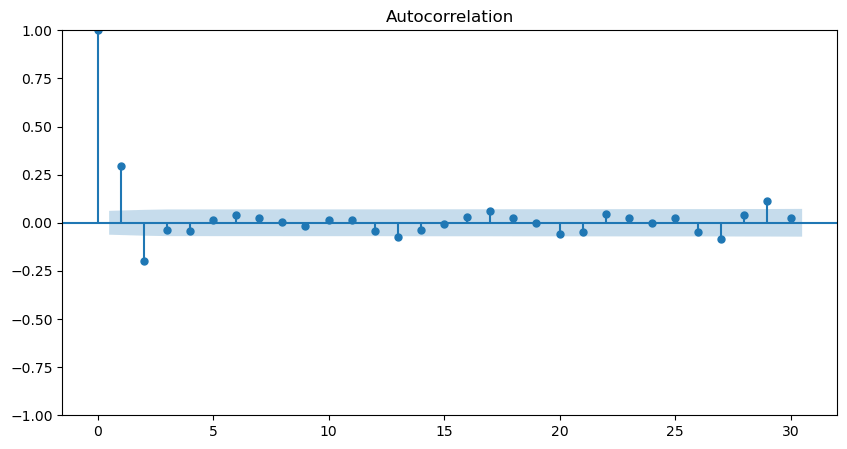

In [56]:
fig, ax = plt.subplots(figsize = (10,5))
plot_acf(ma2, ax=ax);

#### MA(3)

In [57]:
errors = 0.1 * np.random.randn(1000) ## normal distribution with std dev = 0.1
ma3 = []
for i in range(1000):
    # if i>=1:
    x = 0.5 * errors[i-1] - 0.3 * errors[i-2] + 0.7 * errors[i-3] + errors[i]# ma1 is generted by adding current error times b * previous error
    # else:
        # x = errors[i]
    ma3.append(x)
    
ma3 = np.array(ma3)

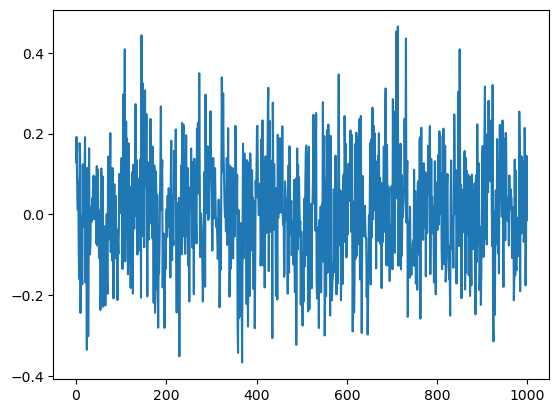

In [58]:
plt.plot(ma3)

In [59]:
adfuller(ma3)

(np.float64(-12.265353940846405),
 np.float64(8.886096422607605e-23),
 5,
 994,
 {'1%': np.float64(-3.43694584277544),
  '5%': np.float64(-2.8644520725172873),
  '10%': np.float64(-2.5683205291305176)},
 np.float64(-1328.0687260272816))

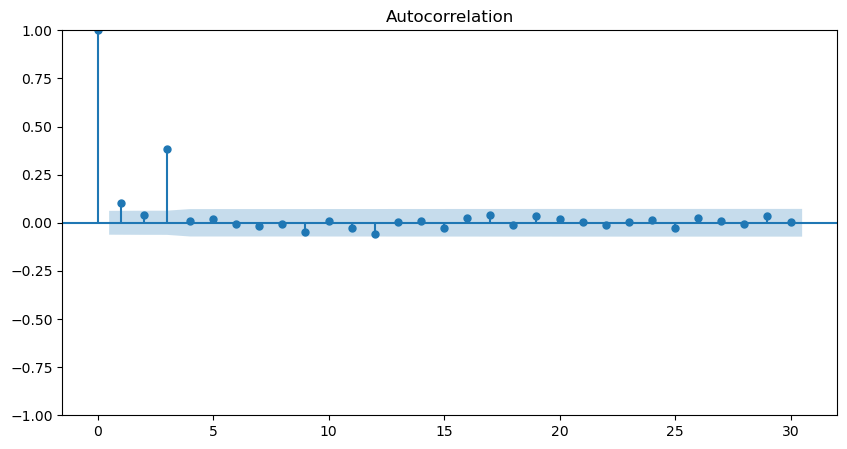

In [60]:
fig, ax = plt.subplots(figsize = (10,5))
plot_acf(ma3, ax=ax);

In [61]:
''' largest non zero lag is 3'''

' largest non zero lag is 3'

#### ma(6)

In [71]:
errors = 0.1 * np.random.randn(1000) ## normal distribution with std dev = 0.1
ma6 = []
for i in range(1000):
    # if i>=1:
    x = 0.5 * errors[i-1] - 0.3 * errors[i-2] + 0.7 * errors[i-3] + \
    0.2 * errors[i-4] - 0.8 * errors[i-5] - 0.9 * errors[i-6] + errors[i]# ma1 is generted by adding current error times b * previous error
    # else:
        # x = errors[i]
    ma6.append(x)
    
ma6 = np.array(ma6)

In [72]:
# errors = 0.1 * np.random.randn(1000) ## normal distribution with std dev = 0.1
# ma6 = []
# for i in range(1000):
#     # if i>=1:
#     x = 0.5 * errors[i-1] - 0.9 * errors[i-6] + errors[i]# ma1 is generted by adding current error times b * previous error
#     # else:
#         # x = errors[i]
#     ma6.append(x)
    
# ma6 = np.array(ma6)

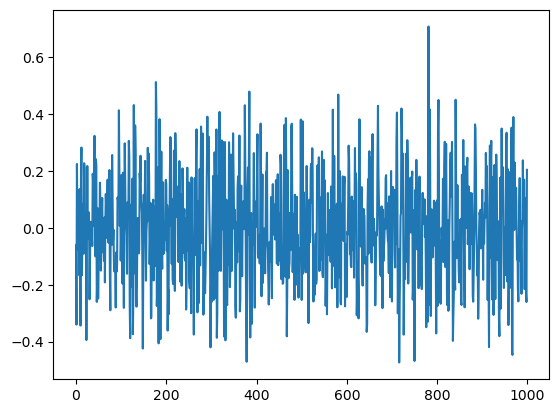

In [73]:
plt.plot(ma6)

In [74]:
adfuller(ma6)

(np.float64(-11.360873703705678),
 np.float64(9.480569805259693e-21),
 16,
 983,
 {'1%': np.float64(-3.4370198458812156),
  '5%': np.float64(-2.864484708707697),
  '10%': np.float64(-2.568337912084273)},
 np.float64(-1026.916065071872))

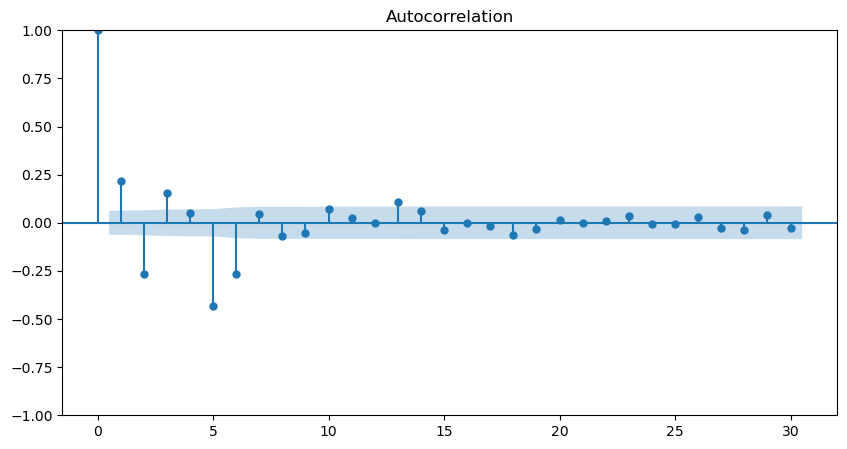

In [75]:
fig, ax = plt.subplots(figsize = (10,5))
plot_acf(ma6, ax=ax);